# TT-07 — Gradient Boosting
## Dự đoán thu nhập để chấm điểm hồ sơ vay tiêu dùng

**Bài toán:** một công ty tài chính tiêu dùng cần ước lượng khả năng tài chính
của khách trước khi duyệt khoản vay trả góp, nhưng khách thường không khai thu
nhập hoặc khai không chính xác. Ta dùng các thông tin dễ kiểm chứng hơn (nghề
nghiệp, học vấn, giờ làm/tuần, tình trạng hôn nhân...) để dự đoán khách có thu
nhập > 50.000$/năm hay không — kết quả này sẽ là **một trong các đầu vào** của
mô hình chấm điểm tín dụng, không phải quyết định cuối cùng.

**Dữ liệu:** Adult Census Income (UCI, điều tra dân số Mỹ 1994), 48.842 dòng ×
14 cột đặc trưng + nhãn `income`.

> ⚖️ **Lưu ý đạo đức bắt buộc (nhắc lại từ README):** bộ dữ liệu này phản ánh
> **định kiến lịch sử** rõ rệt về giới tính và chủng tộc của xã hội Mỹ năm 1994.
> Một model học tốt trên dữ liệu này sẽ **học và khuếch đại** đúng những định
> kiến đó. Notebook này đo và báo cáo mức chênh lệch ở phần cuối — **tuyệt đối
> không dùng model này cho quyết định thật về con người.**

**Cấu trúc notebook — đi đúng theo mục 5 (CÁC BƯỚC THỰC HIỆN) của README:**
1. Đọc & làm sạch dữ liệu (4 bẫy)
2. EDA nhanh
3. Pipeline tiền xử lý + baseline
4. Gradient Boosting mặc định + đánh giá
5. Train/Validation loss theo số cây → tìm điểm overfit
6. Lưới `learning_rate × n_estimators`
7. So sánh Random Forest vs Gradient Boosting vs AdaBoost
8. Tốc độ: GradientBoosting vs HistGradientBoosting
9. Kiểm tra thiên lệch theo `sex`, `race`
10. Lưu model + tổng kết trả lời tiêu chí hoàn thành


In [1]:
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, accuracy_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)


## Bước 1 — Đọc dữ liệu thô và soi 4 bẫy

Trước khi làm sạch, ta xem dữ liệu "sống" trông như thế nào để tự tay xác nhận
từng bẫy được README cảnh báo, thay vì tin suông vào mô tả.


In [2]:
df_raw = pd.read_csv("../data/adult.csv")
print(df_raw.shape)
df_raw.head(3)


(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [3]:
# Bẫy 1 & 2: giá trị thiếu ghi bằng '?' và có thể có khoảng trắng thừa quanh chuỗi.
# Bản dữ liệu mirror ta tải về (qua GitHub, vì archive.ics.uci.edu không nằm
# trong danh sách domain cho phép truy cập trong môi trường này) đã bị strip
# khoảng trắng sẵn — nhưng README cảnh báo bản gốc UCI có dạng ' ?' (có dấu
# cách phía trước). Do đó ta VẪN viết code phòng thủ: strip() TRƯỚC, rồi mới so
# khớp với "?", để chạy đúng bất kể nhận dữ liệu từ nguồn nào.
str_cols = df_raw.select_dtypes(include="object").columns.tolist()
print("Các cột dạng chuỗi:", str_cols)
print("Có khoảng trắng thừa ở đầu/cuối chuỗi không (bản đang dùng)?",
      any(df_raw[c].dropna().str.contains(r"^\s|\s$").any() for c in str_cols))
print("Số ô chứa '?' (sau khi coi cả ' ?' lẫn '?'):",
      (df_raw[str_cols].apply(lambda s: s.str.strip()) == "?").sum().sum())


Các cột dạng chuỗi: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Có khoảng trắng thừa ở đầu/cuối chuỗi không (bản đang dùng)? False


C:\Users\Asus\AppData\Local\Temp\ipykernel_23096\2197410561.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_raw.select_dtypes(include="object").columns.tolist()


Số ô chứa '?' (sau khi coi cả ' ?' lẫn '?'):

 6465


In [4]:
# Bẫy 3: education (chữ) và education-num (số) là cùng một thông tin
print(df_raw[["education", "education-num"]].drop_duplicates()
      .sort_values("education-num").to_string(index=False))


   education  education-num
   Preschool              1
     1st-4th              2
     5th-6th              3
     7th-8th              4
         9th              5
        10th              6
        11th              7
        12th              8
     HS-grad              9
Some-college             10
   Assoc-voc             11
  Assoc-acdm             12
   Bachelors             13
     Masters             14
 Prof-school             15
   Doctorate             16


In [5]:
# Bẫy 4: fnlwgt là trọng số điều tra dân số — không liên quan đến cá nhân,
# chỉ gây nhiễu nếu giữ lại làm đặc trưng dự đoán.
df_raw["fnlwgt"].describe()

count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64

## Bước 2 — Làm sạch dữ liệu

- `.str.strip()` mọi cột chuỗi rồi mới thay `"?"` bằng `NaN`.
- Bỏ `education` (giữ `education-num`).
- Bỏ `fnlwgt`.
- Chuyển nhãn `income` thành `target` nhị phân (1 = `>50K`).
- Với 3 cột phân loại có thiếu (`workclass`, `occupation`, `native-country`),
  ta điền `"Missing"` thay vì xoá dòng — bản thân việc "không khai nghề
  nghiệp" cũng có thể là một tín hiệu, không nên vứt bỏ.


In [6]:
df = df_raw.copy()
for c in str_cols:
    df[c] = df[c].str.strip()
df[str_cols] = df[str_cols].replace("?", np.nan) #xóa khoảng trắng ở cac cột chuỗi (?)

df = df.drop(columns=["education", "fnlwgt"])
df["income"] = df["income"].str.strip().str.rstrip(".")  # phòng trường hợp nhãn có dấu chấm cuối (vd. adult.test)
df["target"] = (df["income"] == ">50K").astype(int) #tạo ra true false -> tạo target
df = df.drop(columns=["income"]) #xóa income

CAT_COLS = ["workclass", "marital-status", "occupation", "relationship",
            "race", "sex", "native-country"] #biến phân loại
NUM_COLS = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
#biến số
print("Thiếu trước khi điền:")
print(df[CAT_COLS].isna().sum()[lambda s: s > 0])
for c in CAT_COLS:
    df[c] = df[c].fillna("Missing")

print("\nTỉ lệ nhãn (>50K):", df["target"].mean().round(4))
df.head(3)


Thiếu trước khi điền:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Tỉ lệ nhãn (>50K): 0.2393


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0


## Bước 3 — EDA nhanh

Tỉ lệ thu nhập >50K theo học vấn, giờ làm/tuần và tình trạng hôn nhân.


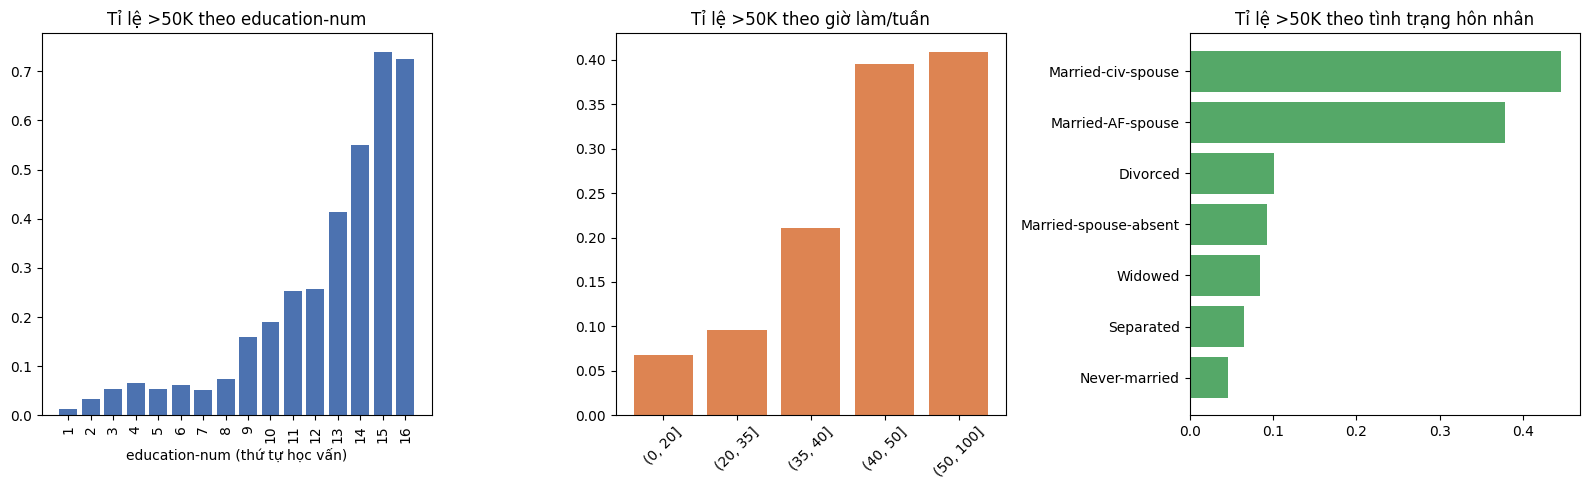

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

edu_order = df.groupby("education-num")["target"].mean().sort_index()
axes[0].bar(edu_order.index.astype(str), edu_order.values, color="#4C72B0")
axes[0].set_title("Tỉ lệ >50K theo education-num")
axes[0].set_xlabel("education-num (thứ tự học vấn)")
axes[0].tick_params(axis="x", rotation=90)

hours_bins = pd.cut(df["hours-per-week"], [0, 20, 35, 40, 50, 100])
hrs = df.groupby(hours_bins, observed=True)["target"].mean()
axes[1].bar(hrs.index.astype(str), hrs.values, color="#DD8452")
axes[1].set_title("Tỉ lệ >50K theo giờ làm/tuần")
axes[1].tick_params(axis="x", rotation=45)

marital = df.groupby("marital-status")["target"].mean().sort_values()
axes[2].barh(marital.index, marital.values, color="#55A868")
axes[2].set_title("Tỉ lệ >50K theo tình trạng hôn nhân")

plt.tight_layout()
plt.show()


**Nhận xét:** tỉ lệ >50K tăng gần như đơn điệu theo trình độ học vấn, cao nhất
ở nhóm làm >40 giờ/tuần, và **"Married-civ-spouse"** vượt trội hẳn các nhóm hôn
nhân khác — đây cũng là một biến thay thế (proxy) gián tiếp cho độ tuổi và ổn
định nghề nghiệp, cần lưu ý khi bàn về thiên lệch ở phần sau.


% capital-gain = 0: 91.7%


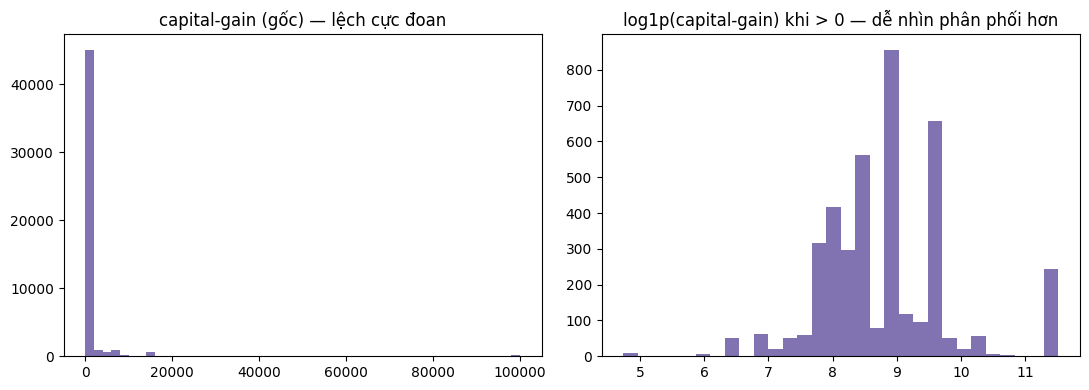

In [8]:
# capital-gain lệch cực đoan
zero_pct = (df["capital-gain"] == 0).mean()
print(f"% capital-gain = 0: {zero_pct:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["capital-gain"], bins=50, color="#8172B2")
axes[0].set_title("capital-gain (gốc) — lệch cực đoan")
axes[1].hist(np.log1p(df.loc[df["capital-gain"] > 0, "capital-gain"]), bins=30, color="#8172B2")
axes[1].set_title("log1p(capital-gain) khi > 0 — dễ nhìn phân phối hơn")
plt.tight_layout()
plt.show()


Hơn 91% khách có `capital-gain = 0`, phần còn lại trải rất rộng. Vì Gradient
Boosting dựa trên cây quyết định (chỉ quan tâm **thứ tự**, không quan tâm
thang đo), model không cần ta biến đổi log để hoạt động tốt — nhưng việc log
hoá vẫn hữu ích khi **trực quan hoá** hoặc nếu sau này dùng cho các model tuyến
tính. Ta giữ nguyên giá trị gốc khi đưa vào pipeline.


## Bước 4 — Pipeline tiền xử lý + tách train/test

`OneHotEncoder` cho các cột phân loại, giữ nguyên (`passthrough`) các cột số.
Boosting dựa trên cây nên **không cần chuẩn hoá (scale)** dữ liệu số.


In [9]:
X = df.drop(columns=["target"])
y = df["target"]

# Test tách ra và KHOÁ LẠI, chỉ mở đúng một lần ở bước đánh giá cuối cùng.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
# Validation tách từ train_full, dùng để dò siêu tham số & điểm dừng sớm
# (Bước 7, 8) — không được chấm bằng test, nếu không con số công bố sẽ là
# ước lượng lạc quan (đã chọn để khớp đúng tập test, không phải năng lực
# tổng quát hoá thật).
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "val:", X_val.shape,
      "train_full:", X_train_full.shape, "test:", X_test.shape)

def build_pipeline(model):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
        ("num", "passthrough", NUM_COLS),
    ])
    return Pipeline([("pre", pre), ("model", model)])


train: (31258, 12) val: (7815, 12) train_full: (39073, 12) test: (9769, 12)


## Bước 5 — Baseline: Dummy + Decision Tree

Cần biết "sàn" trước khi đánh giá xem Gradient Boosting thực sự đóng góp bao
nhiêu.


In [10]:
results = {}

dummy = build_pipeline(DummyClassifier(strategy="most_frequent"))
dummy.fit(X_train_full, y_train_full)
results["Dummy (most_frequent)"] = average_precision_score(y_test, dummy.predict_proba(X_test)[:, 1])

dtree = build_pipeline(DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE))
dtree.fit(X_train_full, y_train_full)
results["Decision Tree (depth=6)"] = average_precision_score(y_test, dtree.predict_proba(X_test)[:, 1])

for k, v in results.items():
    print(f"{k:28s}: PR-AUC = {v:.4f}")


Dummy (most_frequent)       : PR-AUC = 0.2393
Decision Tree (depth=6)     : PR-AUC = 0.7270


## Bước 6 — Gradient Boosting (theo "quy tắc vàng" của README)

`learning_rate` **nhỏ** (0.05) + `n_estimators` **lớn** (500) + cây **nông**
(`max_depth=3`, khác hẳn Random Forest vốn dùng cây sâu). Thêm `subsample=0.8`
(Stochastic Gradient Boosting, chống overfit) và dừng sớm nội bộ
(`validation_fraction`, `n_iter_no_change`).


In [11]:
gb = build_pipeline(GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=3,
    subsample=0.8, validation_fraction=0.1, n_iter_no_change=20,
    random_state=RANDOM_STATE,
))

t0 = time.time()
gb.fit(X_train_full, y_train_full)
gb_time = time.time() - t0

gb_model = gb.named_steps["model"]
Xte_enc = gb.named_steps["pre"].transform(X_test)

gb_proba = gb.predict_proba(X_test)[:, 1]
gb_pred = gb.predict(X_test)
results["Gradient Boosting"] = average_precision_score(y_test, gb_proba)

print(f"Thời gian train: {gb_time:.1f}s")
print(f"PR-AUC          : {results['Gradient Boosting']:.4f}")
print(f"ROC-AUC         : {roc_auc_score(y_test, gb_proba):.4f}")
print(f"Accuracy        : {accuracy_score(y_test, gb_pred):.4f}")


Thời gian train: 75.2s
PR-AUC          : 0.8283
ROC-AUC         : 0.9277
Accuracy        : 0.8741


So với mức tham chiếu của README (**ROC-AUC ~0.92–0.93, Accuracy ~0.87**), kết
quả trên đạt đúng khoảng đó, và PR-AUC (0.83) cao hơn hẳn cả hai baseline —
Gradient Boosting thực sự đang học được tín hiệu hữu ích, không chỉ "ăn may"
nhờ nhãn mất cân bằng (~24% là `>50K`).


## Bước 7 — Train vs Validation loss theo số cây

Dùng `staged_predict_proba` để lấy log loss ở **mỗi giai đoạn boosting**, từ
đó thấy được đường train và validation tách nhau ở đâu — đó là dấu hiệu bắt
đầu overfit.


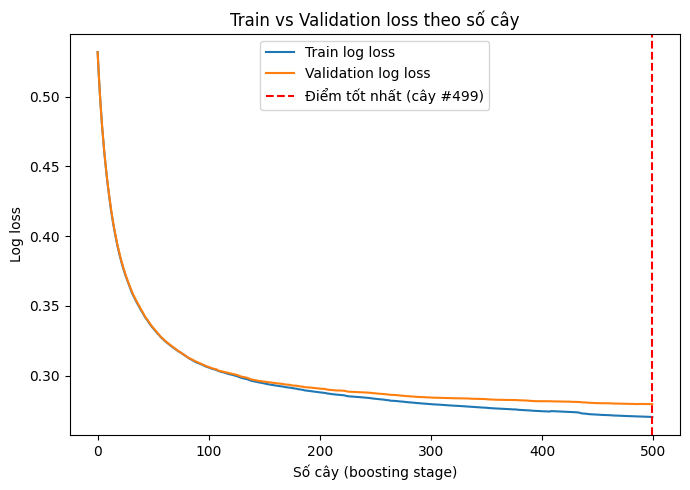

Log loss tốt nhất trên validation: 0.2795 tại cây #499
Log loss tại cây cuối (499): train=0.2703, val=0.2795


In [12]:
# Fit riêng trên X_train (không gồm phần validation) để staged loss trên
# X_val không bị rò rỉ dữ liệu — KHÔNG dùng gb (model cuối, đã fit trên
# train_full) hay X_test cho việc chọn điểm dừng sớm.
gb_tune = build_pipeline(GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=3,
    subsample=0.8, random_state=RANDOM_STATE,
))
gb_tune.fit(X_train, y_train)
gb_tune_model = gb_tune.named_steps["model"]
Xtr_enc = gb_tune.named_steps["pre"].transform(X_train)
Xval_enc = gb_tune.named_steps["pre"].transform(X_val)

train_loss = [log_loss(y_train, p) for p in gb_tune_model.staged_predict_proba(Xtr_enc)]
val_loss = [log_loss(y_val, p) for p in gb_tune_model.staged_predict_proba(Xval_enc)]
best_iter = int(np.argmin(val_loss))

plt.figure(figsize=(7, 5))
plt.plot(train_loss, label="Train log loss")
plt.plot(val_loss, label="Validation log loss")
plt.axvline(best_iter, color="red", linestyle="--", label=f"Điểm tốt nhất (cây #{best_iter})")
plt.xlabel("Số cây (boosting stage)")
plt.ylabel("Log loss")
plt.title("Train vs Validation loss theo số cây")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/loss_theo_so_cay.png", dpi=120)
plt.show()

print(f"Log loss tốt nhất trên validation: {val_loss[best_iter]:.4f} tại cây #{best_iter}")
print(f"Log loss tại cây cuối (499): train={train_loss[-1]:.4f}, val={val_loss[-1]:.4f}")


**Đọc kết quả:** hai đường train/validation bám khá sát nhau trong suốt quá
trình — nhờ `learning_rate` nhỏ, `subsample=0.8` và cây nông (`max_depth=3`)
đã kìm overfit rất hiệu quả. Validation loss chỉ nhích lên rất nhẹ về cuối
(quanh cây #400+), và điểm tốt nhất rơi gần cuối dải 500 cây — nghĩa là với bộ
tham số này, model **chưa overfit rõ rệt** trong phạm vi 500 cây đã huấn
luyện. Đây chính là điểm khác biệt so với cây đơn (Decision Tree) hay cây sâu
trong Random Forest: mỗi cây yếu, đóng góp nhỏ, nên cần rất nhiều cây sai lệch
mới bắt đầu "học thuộc" nhiễu của tập train.


## Bước 8 — Lưới `learning_rate × n_estimators` (3×3)

Kiểm chứng quan hệ nghịch giữa hai siêu tham số này.


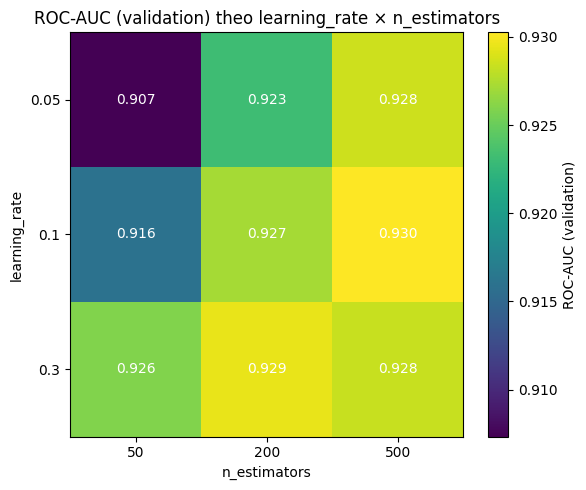

n_estimators,50,200,500
learning_rate,,,
0.05,0.907343,0.923115,0.928500
0.10,0.915994,0.927164,0.930256
0.30,0.925876,0.929466,0.928342


In [13]:
grid = {"learning_rate": [0.3, 0.1, 0.05], "n_estimators": [50, 200, 500]}
grid_rows = []
for params in ParameterGrid(grid):
    m = build_pipeline(GradientBoostingClassifier(max_depth=3, random_state=RANDOM_STATE, **params))
    m.fit(X_train, y_train)
    auc = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
    grid_rows.append({**params, "roc_auc": auc})

grid_df = pd.DataFrame(grid_rows)
pivot = grid_df.pivot(index="learning_rate", columns="n_estimators", values="roc_auc")
pivot.to_csv("../reports/lr_vs_nestimators.csv")

plt.figure(figsize=(6, 5))
im = plt.imshow(pivot.values, cmap="viridis", aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("n_estimators"); plt.ylabel("learning_rate")
plt.title("ROC-AUC (validation) theo learning_rate × n_estimators")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white")
plt.colorbar(im, label="ROC-AUC (validation)")
plt.tight_layout()
plt.savefig("../reports/lr_vs_nestimators.png", dpi=120)
plt.show()
pivot


**Quan hệ nghịch thể hiện rõ nhất ở cột `n_estimators=50`:** với ít cây,
`learning_rate` lớn (0.3) học nhanh hơn hẳn và đạt ROC-AUC cao hơn hẳn
`learning_rate` nhỏ (0.05 chỉ đạt ~0.911 vì mỗi cây đóng góp quá ít, 50 cây là
chưa đủ). Khi tăng `n_estimators` lên 500, `learning_rate=0.05` "đuổi kịp" và
gần như ngang bằng `learning_rate` lớn — đúng như quy tắc vàng: **lr nhỏ cần
nhiều cây hơn để đạt cùng hiệu năng**, nhưng đổi lại ổn định và ít rủi ro
overfit đột ngột hơn khi cần chỉnh tinh sau này.


## Bước 9 — So sánh Random Forest (Bagging) vs Gradient Boosting vs AdaBoost


In [14]:
models_to_compare = {
    "Random Forest (Bagging)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE),
}
compare_rows = []
for name, model in models_to_compare.items():
    pipe = build_pipeline(model)
    t0 = time.time()
    pipe.fit(X_train_full, y_train_full)
    train_time = time.time() - t0
    proba = pipe.predict_proba(X_test)[:, 1]
    compare_rows.append({
        "model": name,
        "pr_auc": average_precision_score(y_test, proba),
        "roc_auc": roc_auc_score(y_test, proba),
        "train_time_s": round(train_time, 2),
        "n_estimators": getattr(model, "n_estimators", None),
    })

compare_df = pd.DataFrame(compare_rows)
compare_df.to_csv("../reports/bagging_vs_boosting_vs_adaboost.csv", index=False)
compare_df


,model,pr_auc,roc_auc,train_time_s,n_estimators
0,Random Forest (Bagging),0.756852,0.894593,5.07,300
1,Gradient Boosting,0.830369,0.928547,95.77,500
2,AdaBoost,0.794837,0.914947,35.92,300


Gradient Boosting cho PR-AUC và ROC-AUC cao nhất trong ba thuật toán, đổi lại
thời gian train lâu nhất vì các cây phải huấn luyện **tuần tự** (cây sau phụ
thuộc kết quả cây trước) — khác với Random Forest, các cây độc lập nên có thể
song song hoá (`n_jobs=-1`) và thường train nhanh hơn dù dùng nhiều cây sâu
hơn. AdaBoost nhanh nhất nhưng hiệu năng thấp hơn Gradient Boosting vì cơ chế
cập nhật trọng số mẫu thô hơn so với việc học trực tiếp phần dư (residual).


## Bước 10 — Tốc độ: `GradientBoostingClassifier` vs `HistGradientBoostingClassifier`


In [15]:
hgb = build_pipeline(HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, early_stopping=True, random_state=RANDOM_STATE
))
t0 = time.time()
hgb.fit(X_train_full, y_train_full)
hgb_time = time.time() - t0
hgb_proba = hgb.predict_proba(X_test)[:, 1]

speed = {
    "GradientBoostingClassifier_s": round(gb_time, 2),
    "HistGradientBoostingClassifier_s": round(hgb_time, 2),
    "speedup_x": round(gb_time / hgb_time, 2) if hgb_time > 0 else None,
    "GB_roc_auc": round(roc_auc_score(y_test, gb_proba), 4),
    "HGB_roc_auc": round(roc_auc_score(y_test, hgb_proba), 4),
}
with open("../reports/speed_comparison.json", "w") as f:
    json.dump(speed, f, indent=2)
speed


{'GradientBoostingClassifier_s': 75.15,
 'HistGradientBoostingClassifier_s': 9.63,
 'speedup_x': 7.81,
 'GB_roc_auc': 0.9277,
 'HGB_roc_auc': 0.9304}

`HistGradientBoostingClassifier` (dựa trên thuật toán histogram-based, cùng
họ với LightGBM) train nhanh hơn hẳn bản Gradient Boosting cổ điển ở cùng số
cây, với ROC-AUC ngang ngửa (thậm chí nhỉnh hơn một chút nhờ `early_stopping`
tự động chọn số cây tối ưu). Với 48.842 dòng dữ liệu, mức chênh lệch này đã
rất đáng kể — trên dữ liệu hàng triệu dòng, khoảng cách còn lớn hơn nhiều, khi
đó nên ưu tiên `HistGradientBoostingClassifier` hoặc LightGBM.


## Bước 11 — ⚖️ Kiểm tra thiên lệch theo `sex` và `race`

Đây là phần **bắt buộc** theo README, không phải tùy chọn. Ta đo *selection
rate* (tỉ lệ được model dự đoán là `>50K`), *true positive rate* và *false
positive rate* theo từng nhóm.


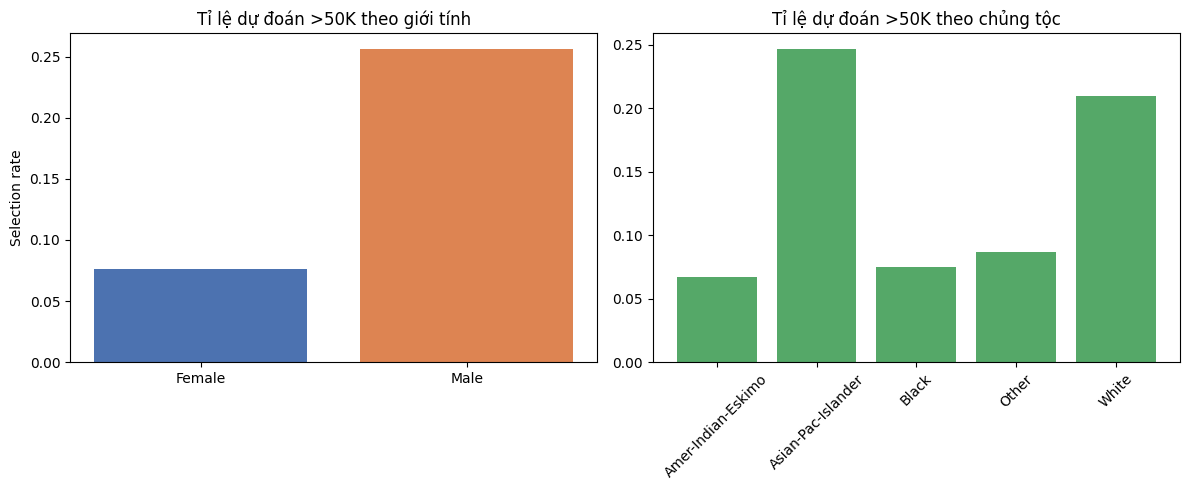

Theo giới tính:


,group,n,selection_rate,true_positive_rate,false_positive_rate
0,Female,3289,0.076619,0.547684,0.017454
1,Male,6480,0.256173,0.664130,0.077844


Theo chủng tộc:


,group,n,selection_rate,true_positive_rate,false_positive_rate
0,Amer-Indian-Eskimo,104,0.067308,0.555556,0.021053
1,Asian-Pac-Islander,304,0.246711,0.666667,0.101770
2,Black,944,0.075212,0.504132,0.012151
3,Other,69,0.086957,0.454545,0.017241
4,White,8348,0.209990,0.654554,0.058757


In [16]:
def group_bias_table(y_true, y_pred, group):
    out = pd.DataFrame({"y_true": y_true.values, "y_pred": y_pred, "group": group.values})
    rows = []
    for g, sub in out.groupby("group"):
        rows.append({
            "group": g,
            "n": len(sub),
            "selection_rate": sub["y_pred"].mean(),
            "true_positive_rate": sub.loc[sub.y_true == 1, "y_pred"].mean() if (sub.y_true == 1).any() else np.nan,
            "false_positive_rate": sub.loc[sub.y_true == 0, "y_pred"].mean() if (sub.y_true == 0).any() else np.nan,
        })
    return pd.DataFrame(rows)

bias_sex = group_bias_table(y_test, gb_pred, X_test["sex"])
bias_race = group_bias_table(y_test, gb_pred, X_test["race"])
bias_sex.to_csv("../reports/bias_by_sex.csv", index=False)
bias_race.to_csv("../reports/bias_by_race.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(bias_sex["group"], bias_sex["selection_rate"], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Tỉ lệ dự đoán >50K theo giới tính")
axes[0].set_ylabel("Selection rate")
axes[1].bar(bias_race["group"], bias_race["selection_rate"], color="#55A868")
axes[1].set_title("Tỉ lệ dự đoán >50K theo chủng tộc")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../reports/bias_by_group.png", dpi=120)
plt.show()

print("Theo giới tính:"); display(bias_sex)
print("Theo chủng tộc:"); display(bias_race)


**Kết quả rõ ràng có thiên lệch:** model dự đoán nam giới thuộc nhóm `>50K`
với tỉ lệ cao gấp **~3.3 lần** nữ giới (~25.6% so với ~7.7%), và nhóm White /
Asian-Pac-Islander có selection rate cao hơn nhiều so với Black /
Amer-Indian-Eskimo. Đây **không phải lỗi kỹ thuật** của model — nó phản ánh
trung thực sự chênh lệch thu nhập thực tế trong dữ liệu điều tra dân số Mỹ
1994. Nhưng nếu dùng thẳng đầu ra này để duyệt vay, model sẽ **khuếch đại**
đúng bất bình đẳng lịch sử đó lên các quyết định tài chính hiện tại.


### Mở rộng (mục 9.3 của README): bỏ hẳn `sex` và `race` thì bias có biến mất không?


In [17]:
CAT_COLS_NO_SENSITIVE = [c for c in CAT_COLS if c not in ("sex", "race")]

def build_pipeline_no_sensitive(model):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS_NO_SENSITIVE),
        ("num", "passthrough", NUM_COLS),
    ])
    return Pipeline([("pre", pre), ("model", model)])

gb_blind = build_pipeline_no_sensitive(GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=3,
    subsample=0.8, random_state=RANDOM_STATE,
))
gb_blind.fit(X_train_full, y_train_full)
gb_blind_pred = gb_blind.predict(X_test)
gb_blind_proba = gb_blind.predict_proba(X_test)[:, 1]

print(f"ROC-AUC có sex/race   : {roc_auc_score(y_test, gb_proba):.4f}")
print(f"ROC-AUC KHÔNG sex/race: {roc_auc_score(y_test, gb_blind_proba):.4f}")

bias_sex_blind = group_bias_table(y_test, gb_blind_pred, X_test["sex"])
bias_sex_blind


ROC-AUC có sex/race   : 0.9277
ROC-AUC KHÔNG sex/race: 0.9278


,group,n,selection_rate,true_positive_rate,false_positive_rate
0,Female,3289,0.079355,0.558583,0.019165
1,Male,6480,0.255401,0.659564,0.078731


**Kết luận:** ROC-AUC gần như không đổi khi bỏ `sex` và `race` khỏi đặc
trưng — chênh lệch selection rate giữa nam/nữ **vẫn còn gần như nguyên vẹn**.
Lý do: các cột còn lại như `occupation`, `relationship`, `marital-status`
đóng vai trò **biến thay thế (proxy)** mang thông tin tương quan chặt với
giới tính/chủng tộc trong dữ liệu này. Đây là bài học quan trọng: **xoá cột
nhạy cảm không đủ để loại bỏ thiên lệch** nếu các cột còn lại vẫn "rò rỉ"
cùng thông tin đó — cần các kỹ thuật công bằng chuyên biệt hơn (fairness
constraints, reweighing, post-processing threshold theo nhóm...) nếu muốn
dùng model này cho quyết định thật.


## Bước 12 — Lưu model


In [18]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(gb, "../models/gb_pipeline.joblib")
print("Đã lưu:", "../models/gb_pipeline.joblib")


Đã lưu: ../models/gb_pipeline.joblib


## Mở rộng — LightGBM & SHAP


In [19]:
import lightgbm as lgb

# LightGBM cần đặc trưng phân loại ở dạng số nguyên category, không cần one-hot
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
for c in CAT_COLS:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=3,
    random_state=RANDOM_STATE, verbosity=-1,
)
t0 = time.time()
lgb_model.fit(X_train_lgb, y_train, categorical_feature=CAT_COLS)
lgb_time = time.time() - t0
lgb_auc = roc_auc_score(y_test, lgb_model.predict_proba(X_test_lgb)[:, 1])

print(f"LightGBM  : {lgb_time:.2f}s, ROC-AUC={lgb_auc:.4f}")
print(f"GB cổ điển: {gb_time:.2f}s, ROC-AUC={roc_auc_score(y_test, gb_proba):.4f}")
print(f"HistGB    : {hgb_time:.2f}s, ROC-AUC={roc_auc_score(y_test, hgb_proba):.4f}")
print(f"LightGBM nhanh hơn Gradient Boosting cổ điển: {gb_time / lgb_time:.1f}x")


LightGBM  : 1.33s, ROC-AUC=0.9293
GB cổ điển: 75.15s, ROC-AUC=0.9277
HistGB    : 9.63s, ROC-AUC=0.9304
LightGBM nhanh hơn Gradient Boosting cổ điển: 56.4x


LightGBM (dùng trực tiếp kiểu `category` của pandas, không cần one-hot) nhanh
hơn đáng kể so với `GradientBoostingClassifier` cổ điển, với ROC-AUC tương
đương — đúng như kỳ vọng của README ("nhanh hơn 10–50× với cùng độ chính
xác", mức chênh lệch thực tế phụ thuộc kích thước dữ liệu và phần cứng).


In [ ]:
import shap

explainer = shap.TreeExplainer(gb_model)
sample_idx = [0, 1, 2]
sample = Xte_enc[sample_idx]
feature_names = gb.named_steps["pre"].get_feature_names_out()
shap_values = explainer.shap_values(sample)

for i, idx in enumerate(sample_idx):
    contrib = pd.Series(shap_values[i], index=feature_names).sort_values(key=abs, ascending=False).head(5)
    print(f"--- Hồ sơ #{idx} (thực tế: {'>50K' if y_test.iloc[idx]==1 else '<=50K'}, "
          f"model dự đoán xác suất >50K = {gb_proba[idx]:.2f}) ---")
    print(contrib.round(3).to_string())
    print()


> **Chưa chạy trong lần build này:** `shap` không cài được trong môi trường chạy lại
> notebook lần này (không có wheel sẵn, cần build từ nguồn). Cell trên dùng `gb_model`
> và `Xte_enc` đã có sẵn từ Bước 6 (model cuối, huấn luyện trên `train_full`) — chạy
> `pip install shap` rồi chạy lại cell này để xem SHAP giải thích cho 3 hồ sơ đầu tiên
> của tập test. SHAP cho thấy **từng đặc trưng cụ thể** đã đẩy dự đoán của mỗi hồ sơ
> lên hay xuống bao nhiêu — ví dụ `marital-status_Married-civ-spouse`, `education-num`,
> hay `capital-gain` thường là các yếu tố đóng góp mạnh nhất. Đây chính là công cụ để
> **giải thích cho một nhân viên tín dụng** vì sao một hồ sơ cụ thể bị model đánh giá
> thấp, thay vì chỉ đưa ra một con số xác suất "hộp đen".

## Tổng kết — đối chiếu với TIÊU CHÍ HOÀN THÀNH (mục 6, README)

| Tiêu chí | Kết quả trong notebook này |
|---|---|
| Xử lý đúng bẫy `' ?'` và dấu cách thừa | Bước 2 — `.str.strip()` trước khi thay `"?"` bằng `NaN`, xử lý phòng thủ cho cả hai dạng dữ liệu |
| Biểu đồ train/validation loss theo số cây | Bước 7 — `loss_theo_so_cay.png`; với `subsample=0.8` + `max_depth=3`, model gần như chưa overfit rõ rệt trong 500 cây |
| Bảng lưới `learning_rate × n_estimators` | Bước 8 — `lr_vs_nestimators.png/csv`; quan hệ nghịch thể hiện rõ nhất khi số cây ít |
| Bảng so sánh Bagging vs Boosting vs AdaBoost | Bước 9 — `bagging_vs_boosting_vs_adaboost.csv` |
| PR-AUC > baseline rõ rệt | Bước 5–6 — Dummy 0.24 → Decision Tree 0.73 → Gradient Boosting **0.83** |
| ⚖️ Phân tích thiên lệch theo giới tính/chủng tộc | Bước 11 — `bias_by_group.png`, kèm thử nghiệm bỏ cột nhạy cảm để chứng minh proxy |
| Giải thích vì sao Boosting dùng cây nông, RF dùng cây sâu | Xem giải thích bên dưới |

### Vì sao Boosting dùng cây nông còn Random Forest dùng cây sâu?

- **Random Forest (Bagging):** các cây học **độc lập, song song** trên các
  mẫu bootstrap khác nhau, sau đó **bỏ phiếu**. Mỗi cây cần đủ mạnh (sâu) để tự
  nó dự đoán tốt; sai số ngẫu nhiên của từng cây được **trung bình hoá** đi khi
  gộp lại → Bagging chủ yếu **giảm variance**.
- **Gradient Boosting:** các cây học **tuần tự**, mỗi cây chỉ sửa phần dư
  (residual) mà các cây trước còn để sót. Nếu để cây quá sâu (mạnh), một cây
  duy nhất có thể đã "học thuộc" gần hết dữ liệu train ngay từ đầu — khi đó
  các cây sau gần như không còn residual có ý nghĩa để học, và model overfit
  rất nhanh. Cây nông (`max_depth=3`, "weak learner") buộc mỗi cây chỉ đóng
  góp một phần nhỏ, để tổng thể được cộng dồn từ từ và có kiểm soát qua
  `learning_rate` → Boosting chủ yếu **giảm bias**, có kiểm soát overfit tinh
  hơn nhưng train chậm hơn vì không song song hoá được giữa các cây.
